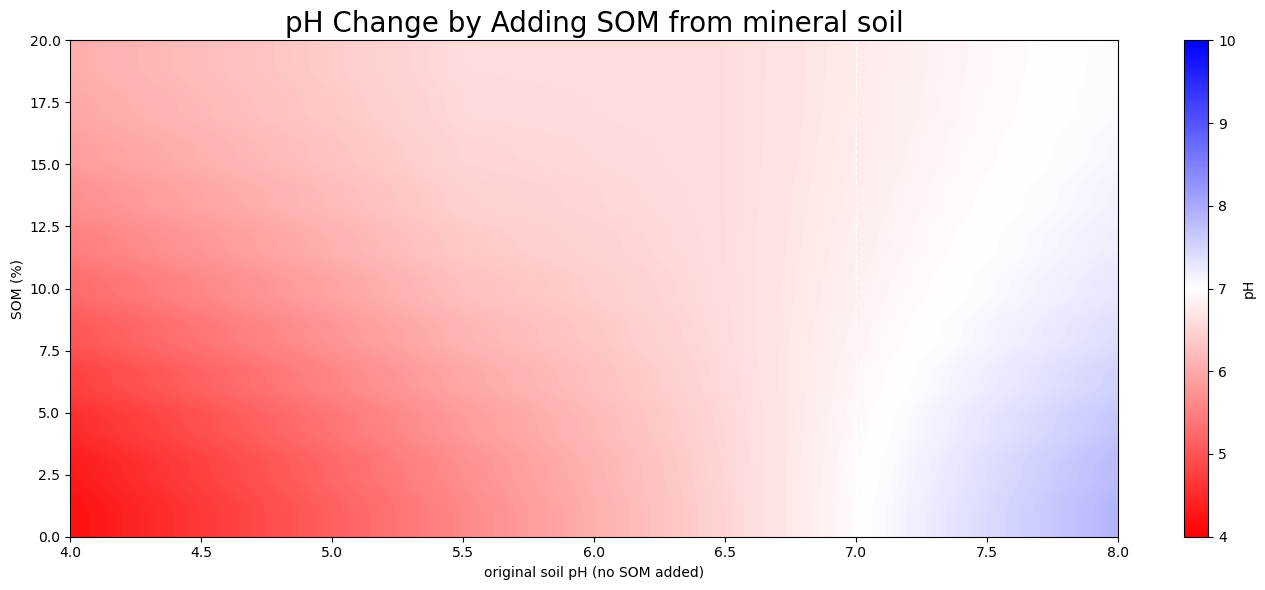

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter
from matplotlib.colors import Normalize, LinearSegmentedColormap

# 定義高解析度的 pH 軸（每 0.01）
initial_pH_highres = np.arange(4.0, 8.001, 0.01)
som_percent = np.arange(0, 22, 2)

# 原始數據（僅 4 組 pH 對應 SOM 曲線）
raw_data_dict = {
    4.5: [4.5, 4.7, 4.9, 5.2, 5.4, 5.6, 5.8, 6.0, 6.1, 6.2, 6.3],
    5.5: [5.5, 5.6, 5.8, 6.0, 6.1, 6.3, 6.4, 6.5, 6.5, 6.6, 6.6],
    6.5: [6.5, 6.5, 6.5, 6.6, 6.6, 6.6, 6.6, 6.6, 6.6, 6.6, 6.6],
    7.5: [7.5, 7.4, 7.3, 7.2, 7.1, 7.0, 7.0, 7.0, 6.9, 6.9, 6.9],
}

# 插值並建立高解析度矩陣
known_pH = np.array(list(raw_data_dict.keys()))
known_curves = np.array(list(raw_data_dict.values()))
data_matrix_highres = np.zeros((len(som_percent), len(initial_pH_highres)))

for i, som in enumerate(som_percent):
    y_vals = known_curves[:, i]
    f_interp = interp1d(known_pH, y_vals, kind='linear', fill_value='extrapolate')
    data_matrix_highres[i, :] = f_interp(initial_pH_highres)

# 高斯平滑（sigma 可調整）
smoothed_matrix = gaussian_filter(data_matrix_highres, sigma=1.5)

# 自訂顏色映射：pH=7.0 為白色
custom_cmap = LinearSegmentedColormap.from_list("custom_cmap", [
    (0.0, "red"),
    (0.5, "white"),
    (1.0, "blue")
])
norm = Normalize(vmin=4.0, vmax=10.0)

# 繪圖
fig, ax = plt.subplots(figsize=(14, 6))
c = ax.imshow(smoothed_matrix, aspect='auto', cmap=custom_cmap, origin='lower',
              extent=[initial_pH_highres[0], initial_pH_highres[-1], som_percent[0], som_percent[-1]],
              norm=norm)

# 加上白色虛線標記 pH = 7.0
ax.axvline(x=7.0, color='white', linestyle='--', linewidth=1)

# 標題與標籤
ax.set_title('pH Change by Adding SOM from mineral soil', fontsize=20)
ax.set_xlabel('original soil pH (no SOM added)')
ax.set_ylabel('SOM (%)')

# 顏色條
cbar = plt.colorbar(c, ax=ax)
cbar.set_label('pH')

plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_147492\1637451020.py:40: UserWarning: Glyph 28611 (\N{CJK UNIFIED IDEOGRAPH-6FC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_147492\1637451020.py:40: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_147492\1637451020.py:40: UserWarning: Glyph 34315 (\N{CJK UNIFIED IDEOGRAPH-860B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_147492\1637451020.py:40: UserWarning: Glyph 26524 (\N{CJK UNIFIED IDEOGRAPH-679C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_147492\1637451020.py:40: UserWarning: Glyph 37240 (\N{CJK UNIFIED IDEOGRAPH-9178}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_147492\1637451020.py:40: UserWarning: Glyph 21508 (\

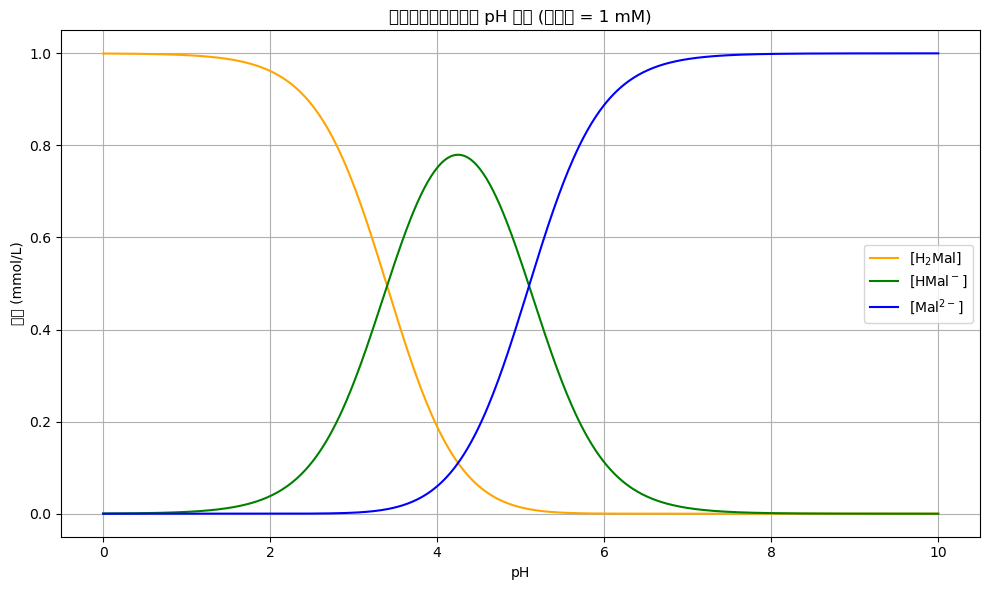

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 蘋果酸的 pKa 值
pKa1 = 3.4  # H2Mal ⇌ HMal⁻ + H⁺
pKa2 = 5.1  # HMal⁻ ⇌ Mal²⁻ + H⁺

# 定義 pH 範圍
pH = np.linspace(0, 10, 500)
H = 10**(-pH)

# 解離常數
Ka1 = 10**(-pKa1)
Ka2 = 10**(-pKa2)

# 各形式分布比例 (α)
denominator = H**2 + Ka1 * H + Ka1 * Ka2
alpha_H2Mal = H**2 / denominator
alpha_HMal = Ka1 * H / denominator
alpha_Mal2 = Ka1 * Ka2 / denominator

# 假設總濃度為 1 mM（0.001 mol/L）
C_total = 1e-3

# 各形式的莫耳濃度
H2Mal_conc = alpha_H2Mal * C_total
HMal_conc = alpha_HMal * C_total
Mal2_conc = alpha_Mal2 * C_total

# 繪圖
plt.figure(figsize=(10, 6))
plt.plot(pH, H2Mal_conc * 1e3, label=r'[H$_2$Mal]', color='orange')
plt.plot(pH, HMal_conc * 1e3, label=r'[HMal$^-$]', color='green')
plt.plot(pH, Mal2_conc * 1e3, label=r'[Mal$^{2-}$]', color='blue')
plt.xlabel('pH')
plt.ylabel('濃度 (mmol/L)')
plt.title('蘋果酸各形式濃度與 pH 變化 (總濃度 = 1 mM)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [2]:
import numpy as np
import pandas as pd

# 定義蘋果酸的 pKa 值
pKa1 = 3.40
pKa2 = 5.11

# 將 pKa 轉為 Ka
Ka1 = 10**(-pKa1)
Ka2 = 10**(-pKa2)

# 要計算的 pH 範圍
pH_values = np.arange(2, 10)  # pH 2 到 9
H_conc = 10.0**(-pH_values)

# 儲存結果的列表
alpha_0 = []  # H2M（未解離）
alpha_1 = []  # HM-（一次解離）
alpha_2 = []  # M2-（完全解離）

# 計算每個 pH 下的各種物種比例
for H in H_conc:
    denom = H**2 + H * Ka1 + Ka1 * Ka2
    a0 = H**2 / denom
    a1 = H * Ka1 / denom
    a2 = Ka1 * Ka2 / denom
    alpha_0.append(a0 * 100)
    alpha_1.append(a1 * 100)
    alpha_2.append(a2 * 100)

# 建立結果表格
df = pd.DataFrame({
    "pH": pH_values,
    "H2M (%)": np.round(alpha_0, 2),
    "HM- (%)": np.round(alpha_1, 2),
    "M2- (%)": np.round(alpha_2, 2)
})

print(df)


   pH  H2M (%)  HM- (%)  M2- (%)
0   2    96.17     3.83     0.00
1   3    71.37    28.41     0.22
2   4    18.90    75.26     5.84
3   5     1.39    55.51    43.09
4   6     0.03    11.41    88.56
5   7     0.00     1.27    98.73
6   8     0.00     0.13    99.87
7   9     0.00     0.01    99.99


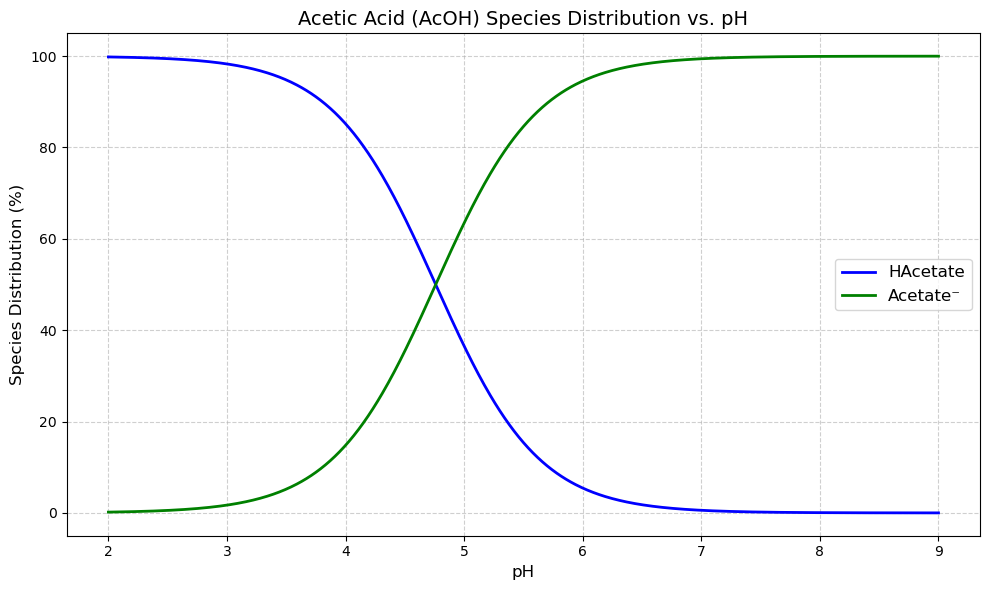

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 定義檸檬酸的 pKa 值
pKa1 = 4.76

# 轉換為 Ka
Ka1 = 10**(-pKa1)

# 更細緻的 pH 範圍，每 0.01 為間距
pH_values = np.arange(2, 9.01, 0.01)
H_conc = 10.0**(-pH_values)

# 儲存結果的列表
alpha_0 = []
alpha_1 = []

# 計算物種比例
for H in H_conc:
    denom = (H) + (Ka1)
    a0 = H / denom
    a1 = Ka1 / denom
    alpha_0.append(a0 * 100)
    alpha_1.append(a1 * 100)

# 畫出圖表
plt.figure(figsize=(10, 6))
plt.plot(pH_values, alpha_0, label="HAcetate", color='blue', linewidth=2)
plt.plot(pH_values, alpha_1, label="Acetate⁻", color='green', linewidth=2)
plt.xlabel("pH", fontsize=12)
plt.ylabel("Species Distribution (%)", fontsize=12)
plt.title("Acetic Acid (AcOH) Species Distribution vs. pH", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

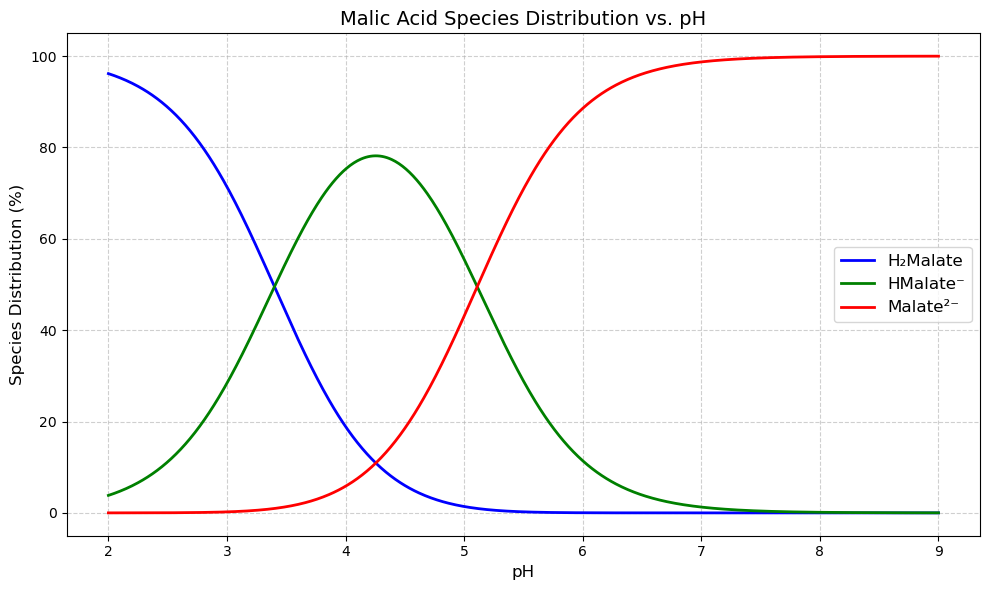

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 定義蘋果酸的 pKa 值
pKa1 = 3.40
pKa2 = 5.11

# 轉換為 Ka
Ka1 = 10**(-pKa1)
Ka2 = 10**(-pKa2)

# 更細緻的 pH 範圍，每 0.01 為間距
pH_values = np.arange(2, 9.01, 0.01)
H_conc = 10.0**(-pH_values)

# 儲存結果的列表
alpha_0 = []
alpha_1 = []
alpha_2 = []

# 計算物種比例
for H in H_conc:
    denom = (H**2) + (H * Ka1) + (Ka1 * Ka2)
    a0 = H**2 / denom
    a1 = H * Ka1 / denom
    a2 = Ka1 * Ka2 / denom
    alpha_0.append(a0 * 100)
    alpha_1.append(a1 * 100)
    alpha_2.append(a2 * 100)

# 畫出圖表
plt.figure(figsize=(10, 6))
plt.plot(pH_values, alpha_0, label="H₂Malate", color='blue', linewidth=2)
plt.plot(pH_values, alpha_1, label="HMalate⁻", color='green', linewidth=2)
plt.plot(pH_values, alpha_2, label="Malate²⁻", color='red', linewidth=2)
plt.xlabel("pH", fontsize=12)
plt.ylabel("Species Distribution (%)", fontsize=12)
plt.title("Malic Acid (H₂Mal) Species Distribution vs. pH", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

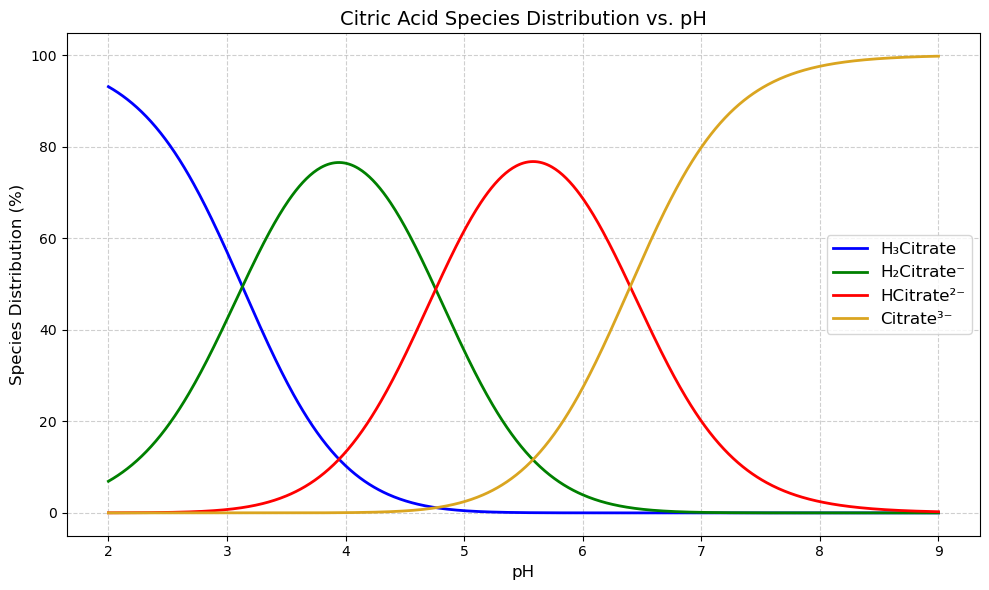

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 定義檸檬酸的 pKa 值
pKa1 = 3.13
pKa2 = 4.76
pKa3 = 6.40

# 轉換為 Ka
Ka1 = 10**(-pKa1)
Ka2 = 10**(-pKa2)
Ka3 = 10**(-pKa3)

# 更細緻的 pH 範圍，每 0.01 為間距
pH_values = np.arange(2, 9.01, 0.01)
H_conc = 10.0**(-pH_values)

# 儲存結果的列表
alpha_0 = []
alpha_1 = []
alpha_2 = []
alpha_3 = []

# 計算物種比例
for H in H_conc:
    denom = (H**3) + (H**2 * Ka1) + (H * Ka1 * Ka2) + (Ka1 * Ka2 * Ka3)
    a0 = H**3 / denom
    a1 = H**2 * Ka1 / denom
    a2 = H * Ka1 * Ka2 / denom
    a3 = Ka1 * Ka2 * Ka3 / denom
    alpha_0.append(a0 * 100)
    alpha_1.append(a1 * 100)
    alpha_2.append(a2 * 100)
    alpha_3.append(a3 * 100)

# 畫出圖表
plt.figure(figsize=(10, 6))
plt.plot(pH_values, alpha_0, label="H₃Citrate", color='blue', linewidth=2)
plt.plot(pH_values, alpha_1, label="H₂Citrate⁻", color='green', linewidth=2)
plt.plot(pH_values, alpha_2, label="HCitrate²⁻", color='red', linewidth=2)
plt.plot(pH_values, alpha_3, label="Citrate³⁻", color='#DAA520', linewidth=2)
plt.xlabel("pH", fontsize=12)
plt.ylabel("Species Distribution (%)", fontsize=12)
plt.title("Citric Acid (H₃Citr) Species Distribution vs. pH", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

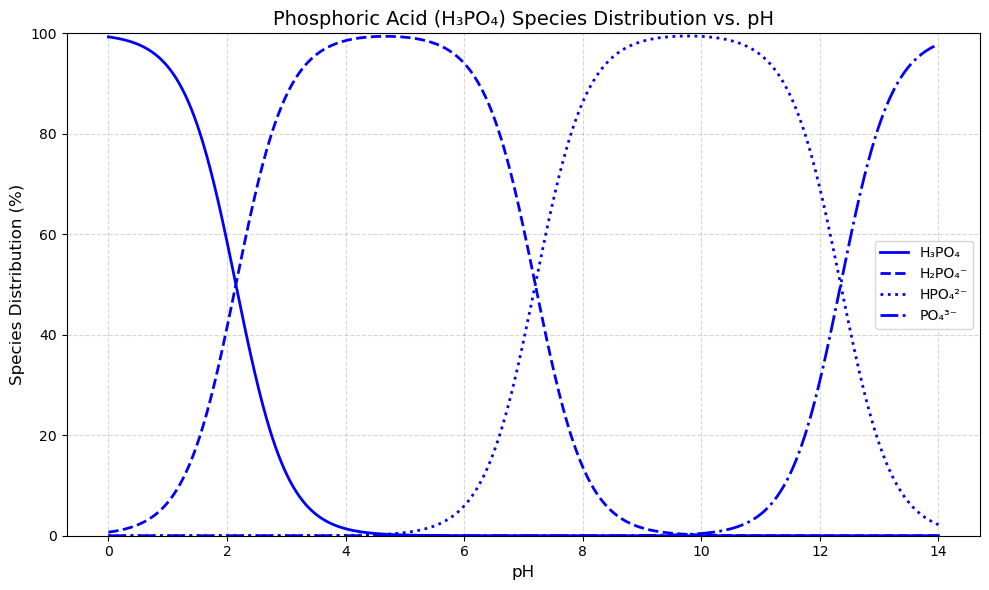

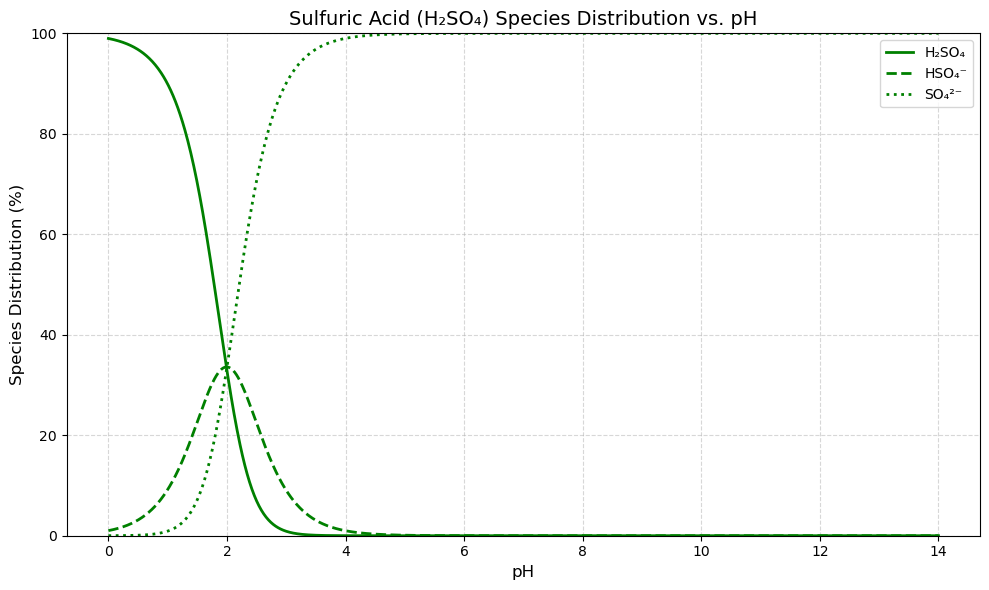

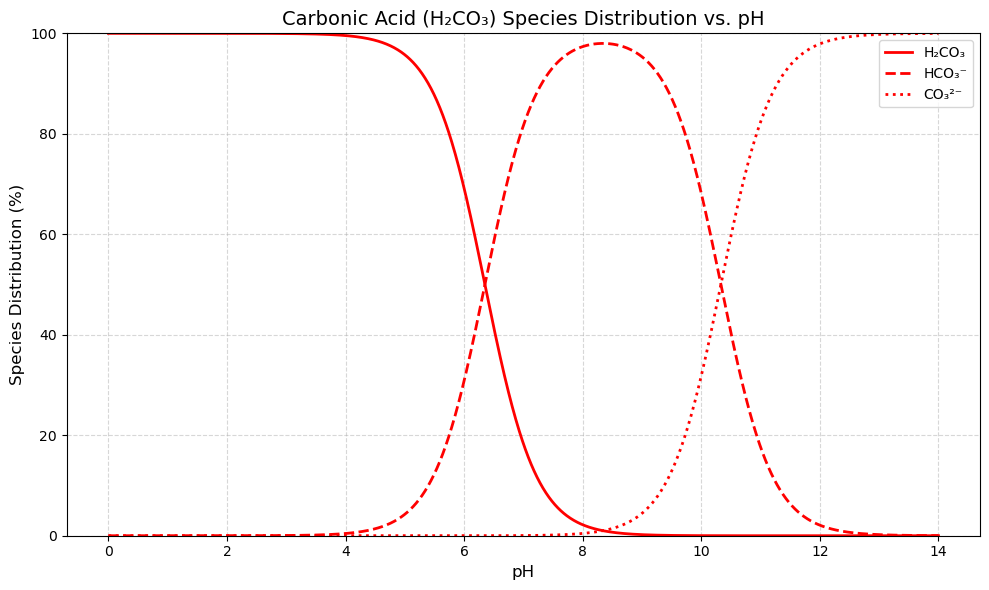

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 定義每種酸的 pKa 值與對應物種標籤
acids = {
    "Phosphoric Acid (H₃PO₄)": {
        "pKa": [2.15, 7.20, 12.35],
        "species": ["H₃PO₄", "H₂PO₄⁻", "HPO₄²⁻", "PO₄³⁻"]
    },
    "Sulfuric Acid (H₂SO₄)": {
        "pKa": [1.99, 2.00],
        "species": ["H₂SO₄", "HSO₄⁻", "SO₄²⁻"]
    },
    "Carbonic Acid (H₂CO₃)": {
        "pKa": [6.35, 10.33],
        "species": ["H₂CO₃", "HCO₃⁻", "CO₃²⁻"]
    }
}

# 顏色設定
acid_colors = {
    "Phosphoric Acid (H₃PO₄)": "blue",
    "Sulfuric Acid (H₂SO₄)": "green",
    "Carbonic Acid (H₂CO₃)": "red"
}

# 線條樣式（依照解離程度）
linestyles = ["-", "--", ":", "-."]

# pH 範圍
pH_values = np.arange(0, 14.01, 0.01)
H = 10**(-pH_values)

# 為每個酸單獨繪圖
for acid_name, acid_info in acids.items():
    pKa_list = acid_info["pKa"]
    species_labels = acid_info["species"]
    Ka = [10**(-pKa) for pKa in pKa_list]
    n = len(Ka)
    color = acid_colors[acid_name]

    # 計算各物種比例
    if n == 2:
        Ka1, Ka2 = Ka
        denom = H**2 + H * Ka1 + Ka1 * Ka2
        alpha = [
            H**2 / denom,
            H * Ka1 / denom,
            Ka1 * Ka2 / denom
        ]
    elif n == 3:
        Ka1, Ka2, Ka3 = Ka
        denom = H**3 + H**2 * Ka1 + H * Ka1 * Ka2 + Ka1 * Ka2 * Ka3
        alpha = [
            H**3 / denom,
            H**2 * Ka1 / denom,
            H * Ka1 * Ka2 / denom,
            Ka1 * Ka2 * Ka3 / denom
        ]

    # 建立單張圖
    plt.figure(figsize=(10, 6))
    for i, a in enumerate(alpha):
        plt.plot(pH_values, a * 100,
                 label=species_labels[i],
                 color=color,
                 linestyle=linestyles[i],
                 linewidth=2)

    plt.title(f"{acid_name} Species Distribution vs. pH", fontsize=14)
    plt.xlabel("pH", fontsize=12)
    plt.ylabel("Species Distribution (%)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(fontsize=10)
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.show()


In [1]:
import sympy as sp

# 定義變量
V1, V2 = sp.symbols('V1 V2')

# 設定氫離子濃度
H1 = 3.98 * 10**-6
H2 = 3.16 * 10**-8
H3 = 3.16 * 10**-7

# 設定方程式
equation = sp.Eq(H3, (H1 * V1 + H2 * V2) / (V1 + V2))

# 求解方程
solution = sp.solve(equation, V1)
solution

[0.0776200873362445*V2]